## Movie Rview

1️⃣ What is a Sentiment RNN (in plain words)?
A Sentiment RNN is:
An RNN (Recurrent Neural Network)
Used for text classification
Output = Positive (1) or Negative (0) sentiment
👉 It reads a sentence one word at a time, remembers context, and decides sentiment at the end.
👉 RNNs remember previous words, unlike traditional ML or simple neural nets.
![alt text](image.png)


* IMDB Dataset
   ↓
* Tokenized & Padded Reviews (X_train, y_train)
   ↓
* PyTorch Dataset & DataLoader
   ↓
* Sentiment Model (RNN / LSTM)
   ↓
* Predicted Sentiment (0 or 1)
   ↓
* Evaluation (Confusion Matrix)
   ↓
* Representation Analysis (t-SNE)


In [4]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
from torch.utils.data import Dataset, DataLoader

# Load IMDB (top 10k words)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Pad reviews to fixed length
MAX_LEN = 200
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN)


In [5]:
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [6]:
train_dataset = IMDBDataset(X_train, y_train)
test_dataset  = IMDBDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)


In [8]:
import torch.nn as nn

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size=10000, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)        # (B, 200, 128)
        _, h = self.rnn(x)           # h: (1, B, 128)
        out = self.fc(h.squeeze(0))  # (B, 1)
        return self.sigmoid(out).squeeze()


In [9]:
model = SentimentRNN()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [10]:
for epoch in range(3):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 252.0599
Epoch 2, Loss: 216.9301
Epoch 3, Loss: 201.0795


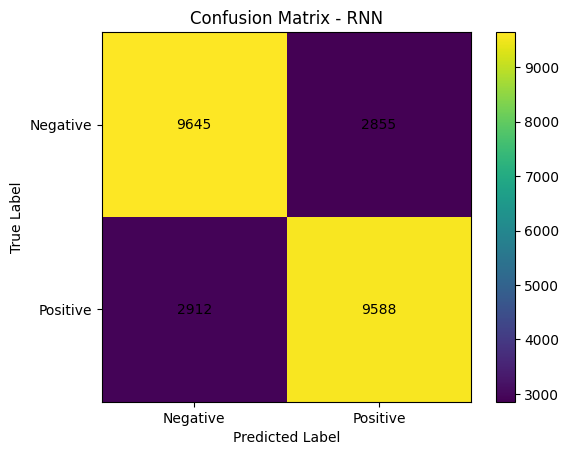

In [ ]:
#Confusion Matrix (RNN)
from sklearn.metrics import confusion_matrix
import numpy as np

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        y_true.extend(y_batch.numpy())
        y_pred.extend((preds > 0.5).int().numpy())

cm_rnn = confusion_matrix(y_true, y_pred)


import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm_rnn)
plt.title("Confusion Matrix - RNN")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

# Add numbers inside cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rnn[i, j],
                 ha="center", va="center")

plt.show()



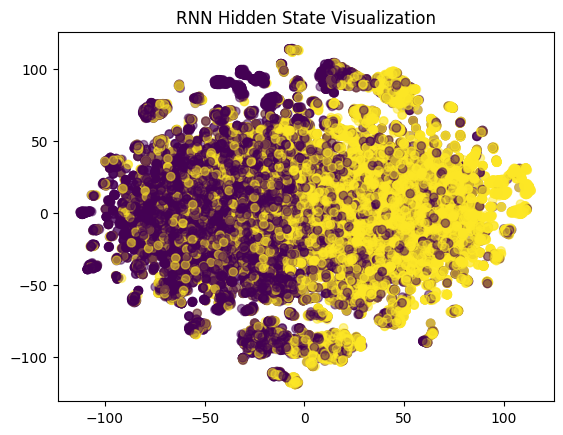

In [ ]:
#Visualise with t-SNE
hidden_states = []
labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        x = model.embedding(X_batch)
        _, h = model.rnn(x)
        hidden_states.append(h.squeeze(0))
        labels.extend(y_batch.numpy())

hidden_states = torch.cat(hidden_states).numpy()

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(hidden_states)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, alpha=0.5)
plt.title("RNN Hidden State Visualization")
plt.show()


In [15]:
#Replace RNN → LSTM (Everything else SAME)
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size=10000, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        out = self.fc(h.squeeze(0))
        return self.sigmoid(out).squeeze()


In [16]:
model = SentimentLSTM(
    vocab_size=10000,
    embed_dim=128,
    hidden_dim=128
)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        preds = model(X_batch)          # ONLY model changed
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 224.5848
Epoch 2, Loss: 183.3721
Epoch 3, Loss: 138.3572


In [17]:
#Evaluate LSTM (SAME evaluation code)
from sklearn.metrics import confusion_matrix
import numpy as np

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        y_true.extend(y_batch.numpy())
        y_pred.extend((preds > 0.5).int().numpy())

cm_lstm = confusion_matrix(y_true, y_pred)
print(cm_lstm)


[[11047  1453]
 [ 2541  9959]]


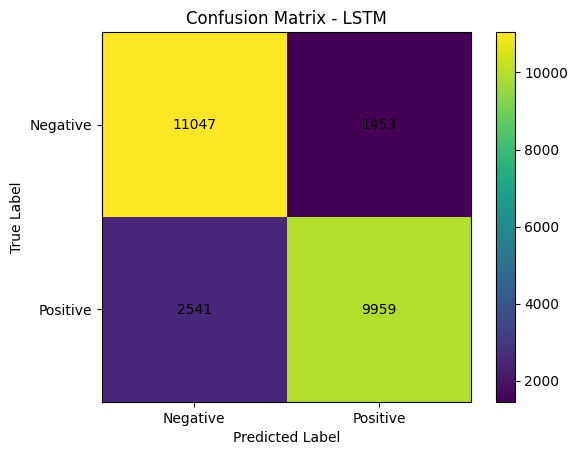

In [18]:
#Plot Confusion Matrix (LSTM)
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm_lstm)
plt.title("Confusion Matrix - LSTM")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lstm[i, j],
                 ha="center", va="center")

plt.show()



In [20]:
#Extract LSTM hidden representations
import torch
import numpy as np

hidden_states = []
labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Embedding
        x = model.embedding(X_batch)          # (B, 200, 128)

        # LSTM forward
        _, (h, _) = model.lstm(x)             # h: (1, B, 128)

        hidden_states.append(h.squeeze(0))    # (B, 128)
        labels.extend(y_batch.numpy())

hidden_states = torch.cat(hidden_states).numpy()  # (N, 128)
labels = np.array(labels)


In [22]:
#Apply t-SNE (dimensionality reduction)
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_2d = tsne.fit_transform(hidden_states)


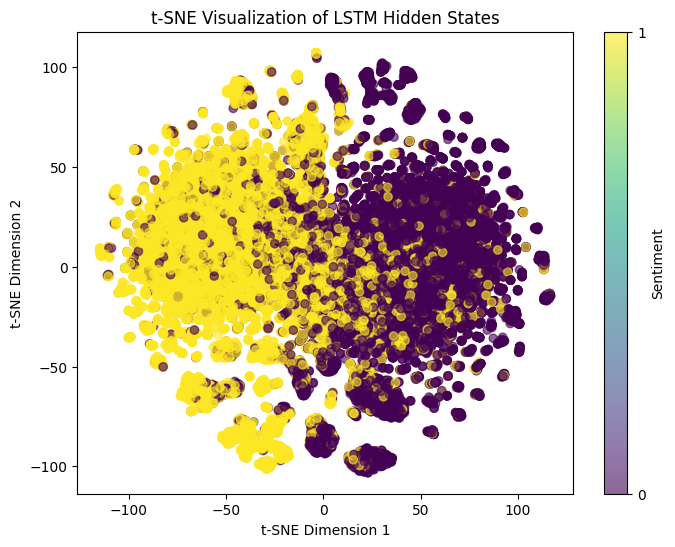

In [23]:
#Plot the t-SNE visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels,
    alpha=0.6
)

plt.title("t-SNE Visualization of LSTM Hidden States")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.colorbar(scatter, ticks=[0, 1], label="Sentiment")
plt.show()
